# TER Picopatt - AlphaEarth

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from functions import load_all
import functions as fc

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import pairwise_distances

import ee

# Auth/Init
ee.Authenticate()
ee.Initialize(project="ee-acombesaguera")

# Tests
print("EE ping:", ee.Number(1).getInfo())

IC_AEF = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
print("AlphaEarth IC size:", IC_AEF.size().getInfo())

img2024 = IC_AEF.filterDate("2024-01-01", "2025-01-01").first()
print("Bands example:", img2024.bandNames().getInfo()[:5])

EE ping: 1
AlphaEarth IC size: 93001
Bands example: ['A00', 'A01', 'A02', 'A03', 'A04']


In [2]:
DATA_NOZERO = Path("outputs/clean_nozeros")
bd = load_all(DATA_NOZERO, False)

# Exiger lon_ontrack/lat_ontrack
required_geo = ["lon_ontrack", "lat_ontrack"]
missing_geo = [c for c in required_geo if c not in bd.columns]
if missing_geo:
    raise ValueError("Colonnes GNSS ontrack manquantes: " + ", ".join(missing_geo))

bd = bd.copy()
bd["lon_std"] = pd.to_numeric(bd["lon_ontrack"], errors="coerce")
bd["lat_std"] = pd.to_numeric(bd["lat_ontrack"], errors="coerce")

# Filtre coordonnées valides
bd = bd.dropna(subset=["lon_std", "lat_std"])
bd = bd[(bd["lon_std"].between(-180, 180)) & (bd["lat_std"].between(-90, 90))]

# UID stable
bd = bd.reset_index(drop=True)
bd["uid"] = bd.index.astype(int)

print("bd ready:", bd.shape)
print("Geo example:", bd[["uid","lon_std","lat_std"]].head())

bd ready: (341281, 42)
Geo example:    uid   lon_std    lat_std
0    0  3.886345  43.608305
1    1  3.886353  43.608305
2    2  3.886361  43.608304
3    3  3.886369  43.608304
4    4  3.886377  43.608303


In [3]:
cols = ["uid", "track_id", "section_id", "lon_std", "lat_std"]
if "point_id" in bd.columns:
    cols.insert(3, "point_id")

pts = bd[cols].copy()
pts = pts.rename(columns={"lon_std":"longitude", "lat_std":"latitude"})

out_csv = Path("picopatt_points.csv")
pts.to_csv(out_csv, index=False)
print("CSV points écrit:", out_csv, "n =", len(pts))

CSV points écrit: picopatt_points.csv n = 341281


Avant de faire la suite du notebook, le csv ``picopatt_points.csv`` doit etre ajouté à earth engine via le bouton Assets puis New.

Ou simplement recupérer le dossier ``alphaearth_exports`` sur le drive du TER puis placer le dossier à la racine du projet.

In [12]:
BANDS = [f"A{i:02d}" for i in range(64)]

EXPORT_DIR = Path("alphaearth_exports")
files = sorted(EXPORT_DIR.glob("PICOPATT_AEF_points_2024_uid_*.csv"))
if not files:
    raise FileNotFoundError("Aucun export AlphaEarth trouvé. Vérifie EXPORT_DIR et les noms de fichiers.")

aef_pts = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Types + contrôles
aef_pts["uid"] = pd.to_numeric(aef_pts["uid"], errors="coerce").astype("Int64")

print("aef_pts shape:", aef_pts.shape)
print("uids uniques:", aef_pts["uid"].nunique(), "min:", aef_pts["uid"].min(), "max:", aef_pts["uid"].max())
print("missing A00:", aef_pts["A00"].isna().sum())

# Vérif bandes
missing_bands = [b for b in BANDS if b not in aef_pts.columns]
if missing_bands:
    raise ValueError("Bandes manquantes dans les exports: " + ", ".join(missing_bands[:10]))

aef_pts shape: (341281, 70)
uids uniques: 341281 min: 0 max: 341280
missing A00: 0


In [13]:
if "uid" not in bd.columns:
    bd = bd.reset_index(drop=True)
    bd["uid"] = bd.index.astype(int)

bd_enriched = bd.merge(aef_pts[["uid"] + BANDS], on="uid", how="left")

print("bd_enriched shape:", bd_enriched.shape)
print("Nb lignes sans embedding (A00 NaN):", bd_enriched["A00"].isna().sum())

bd_enriched shape: (341281, 106)
Nb lignes sans embedding (A00 NaN): 0


In [24]:
CANDIDATES = [
    "tair_thermohygro","tair_tc1","tair_tc2","tair_anemo",
    "rh_thermohygro","ws","wdir",
    "sw_up","sw_front","sw_right",
    "lw_up","lw_down","lw_front","lw_back","lw_left","lw_right",
    "tmrt","pet"
]

METEO = [c for c in CANDIDATES if c in bd_enriched.columns]

# wdir -> sin/cos
if "wdir" in METEO:
    theta = np.deg2rad(pd.to_numeric(bd_enriched["wdir"], errors="coerce") % 360)
    bd_enriched["wdir_sin"] = np.sin(theta)
    bd_enriched["wdir_cos"] = np.cos(theta)
    METEO = [c for c in METEO if c != "wdir"] + ["wdir_sin", "wdir_cos"]

# PCA AlphaEarth
pca = PCA(n_components=10, random_state=0)
aef_pca = pca.fit_transform(bd_enriched[BANDS].to_numpy())
for i in range(10):
    bd_enriched[f"aef_pca_{i+1:02d}"] = aef_pca[:, i]

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print("Variance expliquée PCA(10):", float(cum_explained[-1]))

Variance expliquée PCA(10): 0.9033750519355298


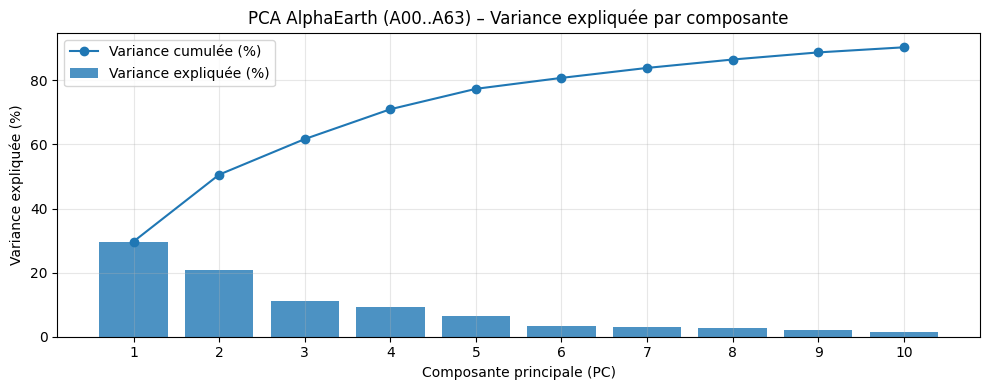

Figure enregistrée: outputs\figures\clusters\alphaearth_pca_explained_variance.png


In [25]:
CLUST = Path("outputs/figures/clusters")
fc.create_folder(CLUST)

plt.figure(figsize=(10, 4))
x = np.arange(1, 11)

plt.bar(x, explained * 100, alpha=0.8, label="Variance expliquée (%)")
plt.plot(x, cum_explained * 100, marker="o", label="Variance cumulée (%)")

plt.xticks(x)
plt.xlabel("Composante principale (PC)")
plt.ylabel("Variance expliquée (%)")
plt.title("PCA AlphaEarth (A00..A63) – Variance expliquée par composante")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_fig = CLUST / "alphaearth_pca_explained_variance.png"
plt.savefig(out_fig, dpi=150)
plt.show()

print("Figure enregistrée:", out_fig)

L’ACP explique 0,903 (90,3 %) de la variance totale avec 10 composantes. Cela indique que les 64 bandes contiennent une forte redondance, et qu’un vecteur réduit (de 10 composantes) conserve l’essentiel de l’information utile.

In [18]:
AE = Path("outputs/alphaearth_data")
fc.create_folder(AE)

BANDS = [f"A{i:02d}" for i in range(64)]
PCA_COLS = [f"aef_pca_{i+1:02d}" for i in range(10)]

if "uid" not in bd_enriched.columns:
    bd_enriched = bd_enriched.reset_index(drop=True)
    bd_enriched["uid"] = bd_enriched.index.astype(int)

missing_cols = [c for c in (["uid"] + BANDS + PCA_COLS) if c not in bd_enriched.columns]
if missing_cols:
    raise ValueError("Colonnes manquantes dans bd_enriched: " + ", ".join(missing_cols[:20]))

# Export PCA 
out_pca = bd_enriched[["uid"] + PCA_COLS].copy()
pca_path = AE / "alphaearth_pca10_points.csv"
out_pca.to_csv(pca_path, index=False)
print("Export PCA10:", pca_path, ", shape:", out_pca.shape)

# Export embeddings bruts
out_raw = bd_enriched[["uid"] + BANDS].copy()
raw_path = AE / "alphaearth_A00_A63_points.csv"
out_raw.to_csv(raw_path, index=False)
print("Export A00..A63:", raw_path, ", shape:", out_raw.shape)

Export PCA10: outputs\alphaearth_data\alphaearth_pca10_points.csv , shape: (341281, 11)
Export A00..A63: outputs\alphaearth_data\alphaearth_A00_A63_points.csv , shape: (341281, 65)


,PC,variance_expliquee,variance_expliquee_pct,variance_cumulee,variance_cumulee_pct
0,1,0.297201,29.720076,0.297201,29.720076
1,2,0.208759,20.875944,0.505960,50.596020
2,3,0.111016,11.101559,0.616976,61.697580
3,4,0.093073,9.307297,0.710049,71.004876
4,5,0.063721,6.372106,0.773770,77.376983
...,...,...,...,...,...
59,60,0.000081,0.008123,0.999782,99.978186
60,61,0.000076,0.007563,0.999857,99.985749
61,62,0.000056,0.005595,0.999913,99.991344
62,63,0.000052,0.005162,0.999965,99.996507


Composantes nécessaires pour 80% : 6
Composantes nécessaires pour 90% : 10
Composantes nécessaires pour 95% : 15


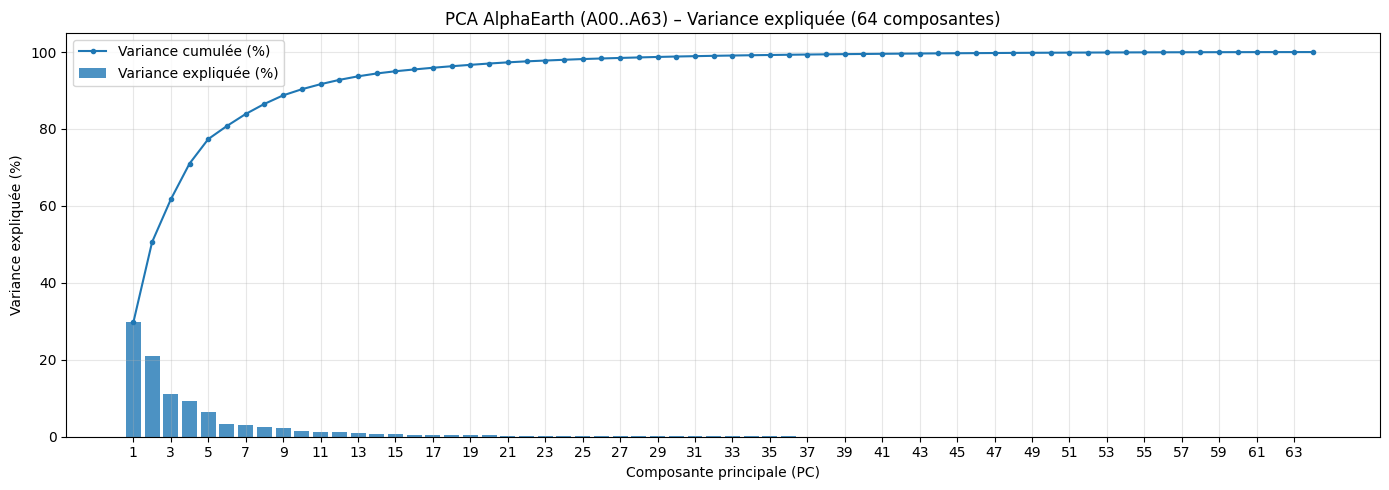

Figure enregistrée: outputs\figures\clusters\alphaearth_pca64_explained_variance.png
Tableau variance exporté: outputs\alphaearth_data\alphaearth_pca64_variance_table.csv


In [ ]:
mask_ok = bd_enriched[BANDS].notna().all(axis=1)
n_drop = int((~mask_ok).sum())
if n_drop > 0:
    print("Lignes exclues PCA(64) (bandes manquantes):", n_drop)

X = bd_enriched.loc[mask_ok, BANDS].to_numpy()


pca64 = PCA(n_components=64, random_state=0)
pca64.fit(X)

explained = pca64.explained_variance_ratio_             
cum_explained = np.cumsum(explained)                     

df_pca_var = pd.DataFrame({
    "PC": np.arange(1, 65),
    "variance_expliquee": explained,
    "variance_expliquee_pct": explained * 100,
    "variance_cumulee": cum_explained,
    "variance_cumulee_pct": cum_explained * 100,
})

display(df_pca_var.head(64))

for thr in [0.80, 0.90, 0.95]:
    n_comp = int(np.searchsorted(cum_explained, thr) + 1)
    print(f"Composantes nécessaires pour {int(thr*100)}% :", n_comp)

plt.figure(figsize=(14, 5))
x = np.arange(1, 65)

plt.bar(x, explained * 100, alpha=0.8, label="Variance expliquée (%)")
plt.plot(x, cum_explained * 100, marker="o", markersize=3, linewidth=1.5, label="Variance cumulée (%)")

plt.xticks(np.arange(1, 65, 2)) 
plt.xlabel("Composante principale (PC)")
plt.ylabel("Variance expliquée (%)")
plt.title("PCA AlphaEarth (A00..A63) – Variance expliquée (64 composantes)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_fig = CLUST / "alphaearth_pca64_explained_variance.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

out_csv = AE / "alphaearth_pca64_variance_table.csv"
df_pca_var.to_csv(out_csv, index=False)
print("Tableau variance exporté:", out_csv)